## **Analisis Komparasi Algoritma YOLO, SSD, dan Faster R-CNN untuk Deteksi Objek Pelanggaran Truk ODOL (Over Dimension Overload)**

**SSD**

CELL 1: Persiapan Lingkungan & Koneksi Google Drive

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Install Library yang dibutuhkan
!pip install roboflow torchmetrics

import os
from roboflow import Roboflow

# PENTING: Ganti dengan API Key milikmu
rf = Roboflow(api_key="mr4rN1CwX8na9vGEIdNh")
project = rf.workspace("indahs-workspace").project("data-indah")
version = project.version(2)
dataset = version.download("yolov8")

dataset_path = dataset.location
print(f"Dataset berhasil diunduh ke lokasi: {dataset_path}")

# Siapkan folder penyimpanan model SSD di Drive
folder_simpan_ssd = '/content/drive/MyDrive/Evaluasi_ODOL/SSD_Hasil'
os.makedirs(folder_simpan_ssd, exist_ok=True)

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 59.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 83.0 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to data-indah-2 in yolov8:: 100%|██████████| 2865/2865 [00:00<00:00, 4048.74it/s]


Dataset berhasil diunduh ke lokasi: /content/data-indah-2


CELL 2: Exploratory Data Analysis (EDA)

📊 Memulai Proses Analisis Data Visual...



Glyph 128248 (\N{CAMERA WITH FLASH}) missing from font(s) DejaVu Sans.
Glyph 128248 (\N{CAMERA WITH FLASH}) missing from font(s) DejaVu Sans.


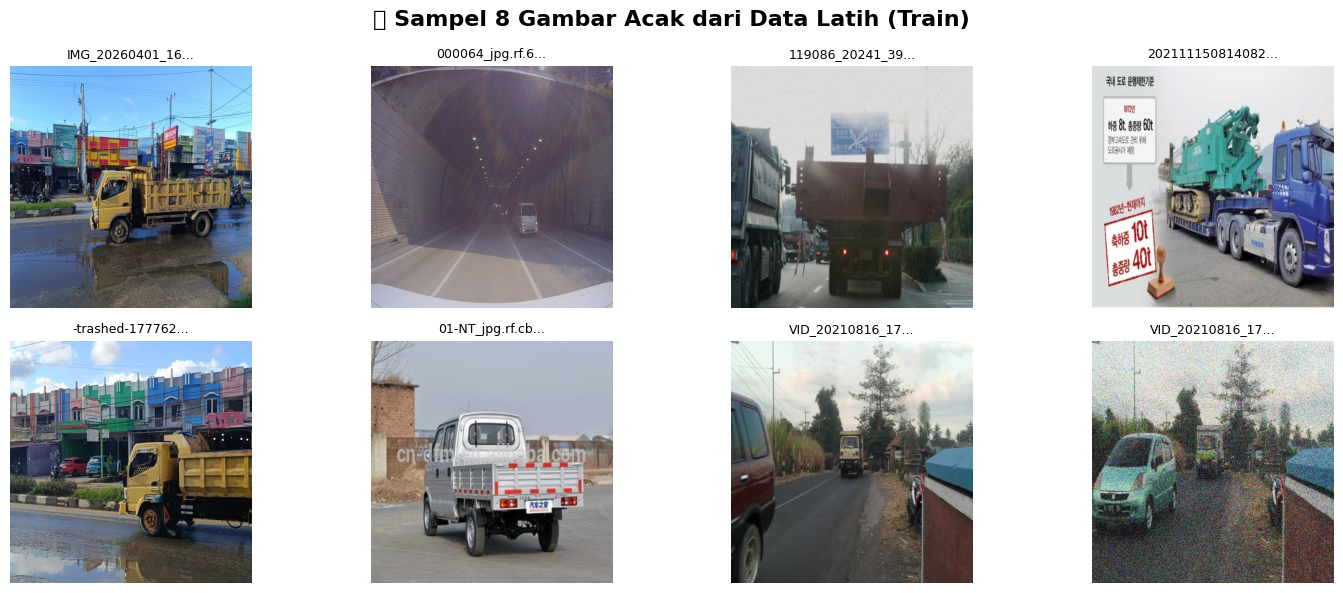

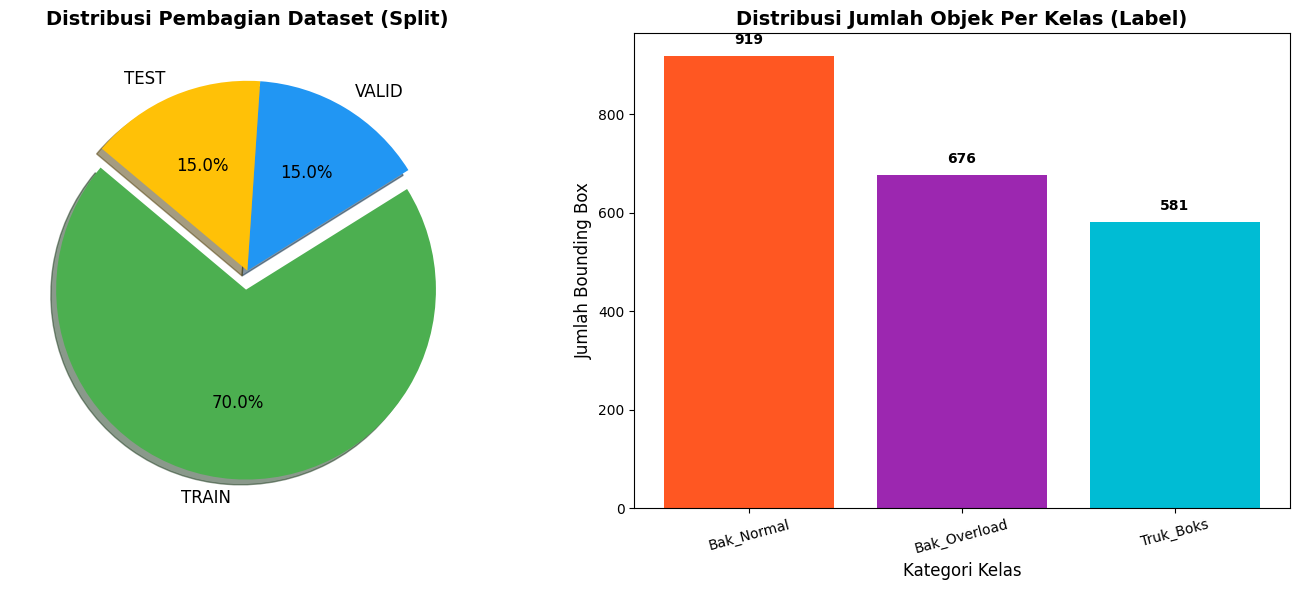


📝 RINGKASAN DATASET:
- Total Kelas Deteksi Asli : 3 Kelas (Bak_Normal, Bak_Overload, Truk_Boks)
- Total Gambar Train       : 1001 gambar
- Total Gambar Valid       : 215 gambar
- Total Gambar Test        : 214 gambar

⚠️ CATATAN PENTING UNTUK (ALGORITMA SSD):
Meskipun grafik di atas menunjukkan 3 kelas, saat masuk ke Cell 3 (DataLoader PyTorch), algoritma SSD akan secara otomatis menambahkan 1 kelas ekstra di memori yaitu 'Background' (Latar Belakang dengan ID 0). Sehingga total kelas operasional yang dilatih oleh SSD adalah 4 kelas. Penjelasan ini wajib dimasukkan ke dalam naskah skripsi Anda.


In [ ]:
import os
import glob
import random
import yaml
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

print("📊 Memulai Proses Analisis Data Visual...\n")

# ==========================================
# 1. VISUALISASI 8 GAMBAR ACAK DARI DATA TRAIN
# ==========================================
train_images = glob.glob(f"{dataset_path}/train/images/*.jpg")

if len(train_images) >= 8:
    gambar_acak = random.sample(train_images, 8)
    plt.figure(figsize=(15, 6))
    plt.suptitle("📸 Sampel 8 Gambar Acak dari Data Latih (Train)", fontsize=16, fontweight='bold')

    for i, img_path in enumerate(gambar_acak):
        img = mpimg.imread(img_path)
        plt.subplot(2, 4, i+1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(os.path.basename(img_path)[:15] + "...", fontsize=9)

    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Gambar di folder Train kurang dari 8 untuk ditampilkan.")

# ==========================================
# 2. PIE CHART & BAR CHART (Sesuai Data Asli)
# ==========================================
splits = ['train', 'valid', 'test']
split_counts = []

# Hitung jumlah gambar per split
for split in splits:
    img_dir = f"{dataset_path}/{split}/images"
    if os.path.exists(img_dir):
        split_counts.append(len(os.listdir(img_dir)))
    else:
        split_counts.append(0)

# Membaca nama kelas dari file data.yaml
yaml_path = f"{dataset_path}/data.yaml"
with open(yaml_path, 'r') as f:
    data_yaml = yaml.safe_load(f)

class_names = data_yaml['names']
class_counts = {name: 0 for name in class_names}

# Menghitung jumlah Bounding Box per kelas
for split in splits:
    label_files = glob.glob(f"{dataset_path}/{split}/labels/*.txt")
    for file in label_files:
        with open(file, 'r') as f:
            lines = f.readlines()
            for line in lines:
                class_id = int(line.split()[0])
                class_counts[class_names[class_id]] += 1

# --- PLOTTING GRAFIK ---
plt.figure(figsize=(14, 6))

# Plot Pie Chart (Sebelah Kiri)
plt.subplot(1, 2, 1)
colors_pie = ['#4CAF50', '#2196F3', '#FFC107'] # Warna Hijau, Biru, Kuning
explode = (0.1, 0, 0)  # Menonjolkan potongan Train
plt.pie(split_counts, labels=[s.upper() for s in splits], autopct='%1.1f%%',
        startangle=140, colors=colors_pie, explode=explode, shadow=True, textprops={'fontsize': 12})
plt.title("Distribusi Pembagian Dataset (Split)", fontsize=14, fontweight='bold')

# Plot Bar Chart (Sebelah Kanan)
plt.subplot(1, 2, 2)
# Warna disesuaikan persis dengan gambar yang Anda lampirkan (Orange, Ungu, Cyan)
colors_bar = ['#FF5722', '#9C27B0', '#00BCD4']
bars = plt.bar(class_counts.keys(), class_counts.values(), color=colors_bar)
plt.title("Distribusi Jumlah Objek Per Kelas (Label)", fontsize=14, fontweight='bold')
plt.xlabel("Kategori Kelas", fontsize=12)
plt.ylabel("Jumlah Bounding Box", fontsize=12)
plt.xticks(rotation=15)

# Menambahkan angka di atas batang grafik
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (max(class_counts.values())*0.02),
             int(yval), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# --- RINGKASAN TEKS ---
print("\n📝 RINGKASAN DATASET:")
print(f"- Total Kelas Deteksi Asli : {len(class_names)} Kelas ({', '.join(class_names)})")
print(f"- Total Gambar Train       : {split_counts[0]} gambar")
print(f"- Total Gambar Valid       : {split_counts[1]} gambar")
print(f"- Total Gambar Test        : {split_counts[2]} gambar")

print("\n⚠️ CATATAN PENTING UNTUK (ALGORITMA SSD):")
print("Meskipun grafik di atas menunjukkan 3 kelas, saat masuk ke Cell 3 (DataLoader PyTorch), algoritma SSD akan secara otomatis menambahkan 1 kelas ekstra di memori yaitu 'Background' (Latar Belakang dengan ID 0). Sehingga total kelas operasional yang dilatih oleh SSD adalah 4 kelas. Penjelasan ini wajib dimasukkan ke dalam naskah skripsi Anda.")

CELL 3: Pre-processing & PyTorch DataLoader

**(Berbeda dengan YOLO)** Algoritma SSD di PyTorch tidak bisa langsung membaca file `.txt` YOLO. SSD membutuhkan format koordinat Bounding Box `[x_min, y_min, x_max, y_max]` dan gambar dalam bentuk *Tensor*. Cell ini berfungsi sebagai "Penerjemah" otomatis.

In [ ]:
import torch
import cv2
import numpy as np
from torch.utils.data import Dataset, DataLoader
import os

class TrukDatasetSSD(Dataset):
    def __init__(self, split):
        self.img_dir = f"{dataset_path}/{split}/images"
        self.label_dir = f"{dataset_path}/{split}/labels"
        self.imgs = [f for f in os.listdir(self.img_dir) if f.endswith('.jpg')]

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img_name = self.imgs[idx]
        img_path = os.path.join(self.img_dir, img_name)
        label_path = os.path.join(self.label_dir, img_name.replace('.jpg', '.txt'))

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img, (300, 300))

        img_tensor = torch.tensor(img_resized.astype(np.float32) / 255.0).permute(2, 0, 1)

        boxes = []
        labels = []
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    data = line.strip().split()
                    class_id = int(data[0]) + 1

                    # --- REVISI LOGIKA CERDAS ---
                    # Ambil semua angka setelah ID kelas dan jadikan list
                    nilai_koordinat = list(map(float, data[1:]))

                    if len(nilai_koordinat) == 4:
                        # 1. Jika ini Bounding Box Standar (cx, cy, w, h)
                        cx, cy, w, h = nilai_koordinat
                        xmin = (cx - w/2) * 300
                        ymin = (cy - h/2) * 300
                        xmax = (cx + w/2) * 300
                        ymax = (cy + h/2) * 300
                    else:
                        # 2. Jika ini adalah Polygon Segmentasi (x1, y1, x2, y2, ...)
                        # Ambil secara melompat: urutan genap adalah X, ganjil adalah Y
                        xs = nilai_koordinat[0::2]
                        ys = nilai_koordinat[1::2]

                        # Buat bounding box dari titik terluar poligon tersebut
                        xmin = min(xs) * 300
                        ymin = min(ys) * 300
                        xmax = max(xs) * 300
                        ymax = max(ys) * 300

                    boxes.append([xmin, ymin, xmax, ymax])
                    labels.append(class_id)

        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)

        target = {"boxes": boxes, "labels": labels}
        return img_tensor, target

def collate_fn(batch):
    return tuple(zip(*batch))

train_dataset = TrukDatasetSSD('train')
val_dataset = TrukDatasetSSD('valid')

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn)

print(f"✅ DataLoader Cerdas Siap! Total data latih: {len(train_dataset)} gambar.")

✅ DataLoader Cerdas Siap! Total data latih: 1001 gambar.


CELL 4: Training Model SSD300 (VGG16 Backbone)

In [ ]:
import torchvision
from torchvision.models.detection import ssd300_vgg16
from torchvision.models.detection.ssd import SSD300_VGG16_Weights
import torch.optim as optim
import torch

# 1. Persiapan Device (GPU)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"💻 Menggunakan perangkat: {device.type.upper()}")

# 2. Panggil Arsitektur SSD
num_classes = len(class_names) + 1
model = ssd300_vgg16(weights=SSD300_VGG16_Weights.DEFAULT)

# Sesuaikan "kepala" prediksi SSD
from torchvision.models.detection.ssd import SSDHead
in_channels = torchvision.models.detection._utils.retrieve_out_channels(model.backbone, (300, 300))
num_anchors = model.anchor_generator.num_anchors_per_location()
model.head = SSDHead(in_channels, num_anchors, num_classes)

model = model.to(device)

# 3. Pengaturan Training (Hyperparameters)
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=0.0005)
epochs = 30

# --- TAMBAHAN UNTUK GRAFIK ---
history_loss = []
# -----------------------------

print("\n🚀 Memulai Proses Training SSD... (Data sedang direkam untuk grafik)")

best_loss = float('inf')

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, targets in train_loader:
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_loss += losses.item()

    avg_loss = total_loss / len(train_loader)

    # --- SIMPAN DATA KE HISTORY ---
    history_loss.append(avg_loss)
    # ------------------------------

    print(f"Epoch [{epoch+1}/{epochs}] - Rata-rata Loss: {avg_loss:.4f}")

    if avg_loss < best_loss:
        best_loss = avg_loss
        simpan_path = f"{folder_simpan_ssd}/best_ssd.pth"
        torch.save(model.state_dict(), simpan_path)

print(f"\n✅ Training Selesai! Data history_loss siap divisualisasikan.")

💻 Menggunakan perangkat: CUDA
Downloading: "https://download.pytorch.org/models/ssd300_vgg16_coco-b556d3b4.pth" to /root/.cache/torch/hub/checkpoints/ssd300_vgg16_coco-b556d3b4.pth


100%|██████████| 136M/136M [00:00<00:00, 189MB/s]



🚀 Memulai Proses Training SSD... (Data sedang direkam untuk grafik)
Epoch [1/30] - Rata-rata Loss: 6.7469
Epoch [2/30] - Rata-rata Loss: 5.2229
Epoch [3/30] - Rata-rata Loss: 4.4199
Epoch [4/30] - Rata-rata Loss: 3.4907
Epoch [5/30] - Rata-rata Loss: 2.8322
Epoch [6/30] - Rata-rata Loss: 2.3088
Epoch [7/30] - Rata-rata Loss: 1.8843
Epoch [8/30] - Rata-rata Loss: 1.6146
Epoch [9/30] - Rata-rata Loss: 3.4844
Epoch [10/30] - Rata-rata Loss: 1.8348
Epoch [11/30] - Rata-rata Loss: 1.3864
Epoch [12/30] - Rata-rata Loss: 1.1285
Epoch [13/30] - Rata-rata Loss: 0.9855
Epoch [14/30] - Rata-rata Loss: 0.8860
Epoch [15/30] - Rata-rata Loss: 0.9044
Epoch [16/30] - Rata-rata Loss: 0.7680
Epoch [17/30] - Rata-rata Loss: 0.6563
Epoch [18/30] - Rata-rata Loss: 0.5870
Epoch [19/30] - Rata-rata Loss: 0.5174
Epoch [20/30] - Rata-rata Loss: 0.5023
Epoch [21/30] - Rata-rata Loss: 0.4488
Epoch [22/30] - Rata-rata Loss: 0.4302
Epoch [23/30] - Rata-rata Loss: 0.4016
Epoch [24/30] - Rata-rata Loss: 0.3456
Epoc

CELL 4b: Visualisasi Kurva Evaluasi Training (Loss)

📊 Menggambar Kurva Loss SSD...


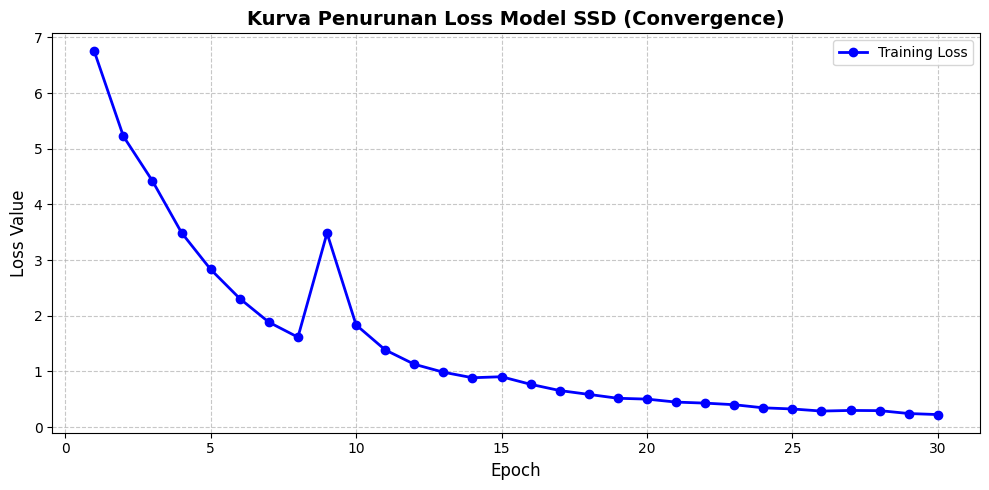

✅ Grafik ini membuktikan model SSD Anda 'belajar' seiring bertambahnya waktu.


In [ ]:
import matplotlib.pyplot as plt

# Pastikan cell ini baru dijalankan SETELAH Cell 4 selesai 100%
print("📊 Menggambar Kurva Loss SSD...")

plt.figure(figsize=(10, 5))
# Membuat grafik garis dari data history_loss yang direkam di Cell 4
plt.plot(range(1, epochs + 1), history_loss, color='blue', marker='o', linestyle='-', linewidth=2, label='Training Loss')

plt.title('Kurva Penurunan Loss Model SSD (Convergence)', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss Value', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

print("✅ Grafik ini membuktikan model SSD Anda 'belajar' seiring bertambahnya waktu.")

CELL 5: Evaluasi Kuantitatif pada Data Uji (Unseen Data)

In [ ]:
import time
import torch
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torch.utils.data import DataLoader

print("1. Memanggil 'otak' model terbaik SSD...")
test_dataset = TrukDatasetSSD('test')
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn)

path_model_terbaik = f"{folder_simpan_ssd}/best_ssd.pth"
model.load_state_dict(torch.load(path_model_terbaik))
model.eval()

print("\n2. Memulai Ujian Akhir pada data TEST...")

# --- TRIK DUA KALKULATOR ---
# Kalkulator 1: Khusus mAP@50 (seperti YOLO)
metric_50 = MeanAveragePrecision(iou_type="bbox", class_metrics=True, iou_thresholds=[0.5])
# Kalkulator 2: Khusus mAP@50-95 & Recall
metric_all = MeanAveragePrecision(iou_type="bbox", class_metrics=True)

total_images = len(test_dataset)
instances_per_class = {i+1: 0 for i in range(len(class_names))}

for _, target in test_dataset:
    for label in target['labels']:
        instances_per_class[label.item()] += 1
total_instances = sum(instances_per_class.values())

start_time = time.time()

with torch.no_grad():
    for images, targets in test_loader:
        images = list(img.to(device) for img in images)
        preds = model(images)

        preds_metric = [{"boxes": p["boxes"].cpu(), "scores": p["scores"].cpu(), "labels": p["labels"].cpu()} for p in preds]
        targets_metric = [{"boxes": t["boxes"].cpu(), "labels": t["labels"].cpu()} for t in targets]

        # Beri makan kedua kalkulator secara bersamaan
        metric_50.update(preds_metric, targets_metric)
        metric_all.update(preds_metric, targets_metric)

end_time = time.time()
waktu_inferensi_ms = ((end_time - start_time) / total_images) * 1000

print("Evaluasi selesai, memproses metrik tabel...\n")
hasil_50 = metric_50.compute()
hasil_all = metric_all.compute()

# Ambil nilai Rata-rata
map50_all = hasil_50['map'].item() # Karena dilock di 0.5, 'map' adalah mAP50
map_all = hasil_all['map'].item()
mar_all = hasil_all['mar_100'].item()

# Ambil nilai per Kelas
map50_cls = hasil_50['map_per_class'].tolist()
map_cls = hasil_all['map_per_class'].tolist()
mar_cls = hasil_all['mar_100_per_class'].tolist()


print(f"{'Class':>20} {'Images':>10} {'Instances':>10} {'mAR(Recall)':>15} {'mAP50':>10} {'mAP50-95':>10}")
print(f"{'all':>20} {total_images:>10} {total_instances:>10} {mar_all:>15.3f} {map50_all:>10.3f} {map_all:>10.3f}")

for i, cls_name in enumerate(class_names):
    if map50_cls[i] != -1:
        print(f"{cls_name:>20} {'-':>10} {instances_per_class[i+1]:>10} {mar_cls[i]:>15.3f} {map50_cls[i]:>10.3f} {map_cls[i]:>10.3f}")

print(f"\nSpeed: {waktu_inferensi_ms:.1f}ms inference per image pada {device.type.upper()}")
print(f"Results saved to {folder_simpan_ssd}")

print("\n" + "="*50)
print("🎯 EVALUASI TEST SSD SELESAI!")
print("="*50)
print("RANGKUMAN NILAI RATA-RATA (KESELURUHAN KELAS):")
print(f"- Mean Recall (mAR)  : {mar_all:.4f} ({mar_all*100:.2f}%)")
print(f"- mAP@50             : {map50_all:.4f} ({map50_all*100:.2f}%)")
print(f"- mAP@50-95          : {map_all:.4f} ({map_all*100:.2f}%)")
print("="*50)
print("Silakan catat nilai persentase di atas langsung ke tabel komparasi skripsimu!")

1. Memanggil 'otak' model terbaik SSD...

2. Memulai Ujian Akhir pada data TEST...


Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.


Evaluasi selesai, memproses metrik tabel...

               Class     Images  Instances     mAR(Recall)      mAP50   mAP50-95
                 all        214        305           0.817      0.914      0.751
          Bak_Normal          -        133           0.768      0.873      0.686
        Bak_Overload          -         82           0.867      0.983      0.831
           Truk_Boks          -         90           0.817      0.886      0.736

Speed: 20.6ms inference per image pada CUDA
Results saved to /content/drive/MyDrive/Evaluasi_ODOL/SSD_Hasil

🎯 EVALUASI TEST SSD SELESAI!
RANGKUMAN NILAI RATA-RATA (KESELURUHAN KELAS):
- Mean Recall (mAR)  : 0.8174 (81.74%)
- mAP@50             : 0.9140 (91.40%)
- mAP@50-95          : 0.7510 (75.10%)
Silakan catat nilai persentase di atas langsung ke tabel komparasi skripsimu!


CELL 6: Visualisasi Confusion Matrix SSD (Custom)

Karena PyTorch tidak memiliki pembuat Confusion Matrix otomatis untuk deteksi objek, cell ini membangun algoritma pencocokan Bounding Box secara mandiri. yaitu: Jika kotak prediksi menindih kotak asli dengan akurasi IoU > 50%, maka dianggap Benar (True Positive). Jika model menebak objek di tempat kosong, masuk ke kategori Background (False Positive).

🔄 Membangun Confusion Matrix secara manual menggunakan logika IoU...



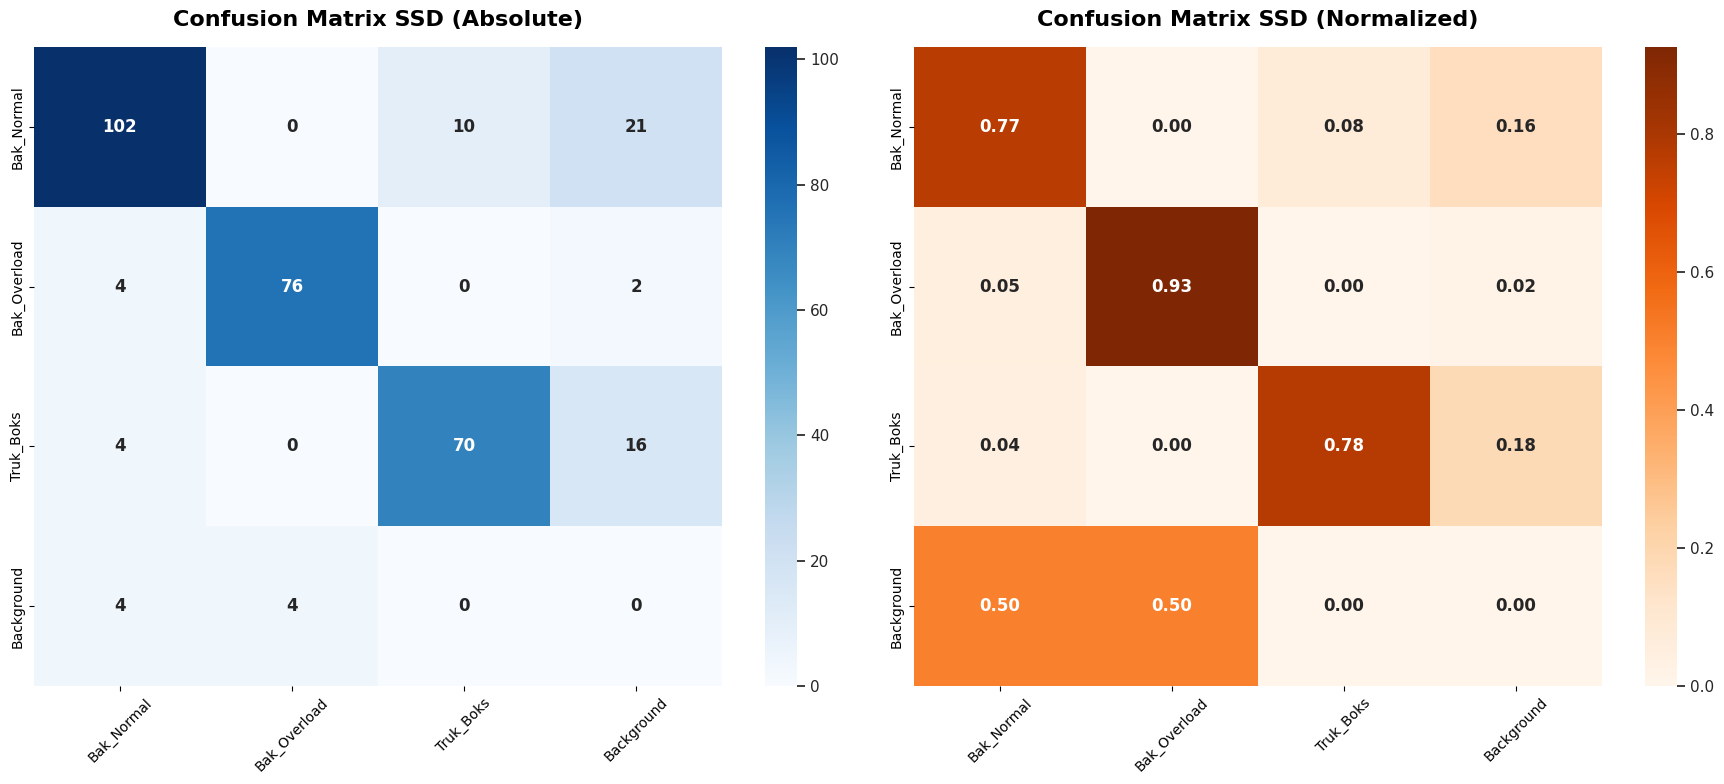

In [ ]:
import torch
import torchvision.ops as ops
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("🔄 Membangun Confusion Matrix secara manual menggunakan logika IoU...\n")

num_kelas_truk = len(class_names)
ukuran_matriks = num_kelas_truk + 1
conf_matrix = np.zeros((ukuran_matriks, ukuran_matriks), dtype=int)
label_matriks = class_names + ['Background']

CONF_THRESH = 0.5
IOU_THRESH = 0.5

model.eval()
with torch.no_grad():
    for images, targets in test_loader:
        images = list(img.to(device) for img in images)
        preds = model(images)

        for p, t in zip(preds, targets):
            pred_boxes = p["boxes"].cpu()
            pred_scores = p["scores"].cpu()
            pred_labels = p["labels"].cpu() - 1

            gt_boxes = t["boxes"].cpu()
            gt_labels = t["labels"].cpu() - 1

            keep = pred_scores >= CONF_THRESH
            pred_boxes = pred_boxes[keep]
            pred_labels = pred_labels[keep]

            if len(gt_boxes) == 0 and len(pred_boxes) == 0:
                continue

            ious = ops.box_iou(gt_boxes, pred_boxes)
            gt_matched = np.zeros(len(gt_boxes), dtype=bool)
            pred_matched = np.zeros(len(pred_boxes), dtype=bool)

            for gt_idx in range(len(gt_boxes)):
                if len(pred_boxes) == 0:
                    break
                best_iou_idx = torch.argmax(ious[gt_idx]).item()
                best_iou_val = ious[gt_idx][best_iou_idx].item()

                if best_iou_val >= IOU_THRESH and not pred_matched[best_iou_idx]:
                    gl = gt_labels[gt_idx].item()
                    pl = pred_labels[best_iou_idx].item()
                    conf_matrix[gl, pl] += 1
                    gt_matched[gt_idx] = True
                    pred_matched[best_iou_idx] = True

            for gt_idx, matched in enumerate(gt_matched):
                if not matched:
                    gl = gt_labels[gt_idx].item()
                    conf_matrix[gl, ukuran_matriks-1] += 1

            for pred_idx, matched in enumerate(pred_matched):
                if not matched:
                    pl = pred_labels[pred_idx].item()
                    conf_matrix[ukuran_matriks-1, pl] += 1

row_sums = conf_matrix.sum(axis=1, keepdims=True)
conf_matrix_norm = conf_matrix / (row_sums + 1e-6)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
sns.set_theme(style="white")

sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=label_matriks, yticklabels=label_matriks,
            annot_kws={"size": 12, "weight": "bold"})
axes[0].set_title('Confusion Matrix SSD (Absolute)', fontsize=16, fontweight='bold', pad=15)
axes[0].set_ylabel('')  # Kosongkan label sumbu Y
axes[0].set_xlabel('')  # Kosongkan label sumbu X
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(conf_matrix_norm, annot=True, fmt=".2f", cmap="Oranges", ax=axes[1],
            xticklabels=label_matriks, yticklabels=label_matriks,
            annot_kws={"size": 12, "weight": "bold"})
axes[1].set_title('Confusion Matrix SSD (Normalized)', fontsize=16, fontweight='bold', pad=15)
axes[1].set_ylabel('')  # Kosongkan label sumbu Y
axes[1].set_xlabel('')  # Kosongkan label sumbu X
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


CELL 7: Prediksi Visual pada Data Test

1. Mempersiapkan model SSD terbaik...
2. Mengambil 8 gambar acak dari data Test...



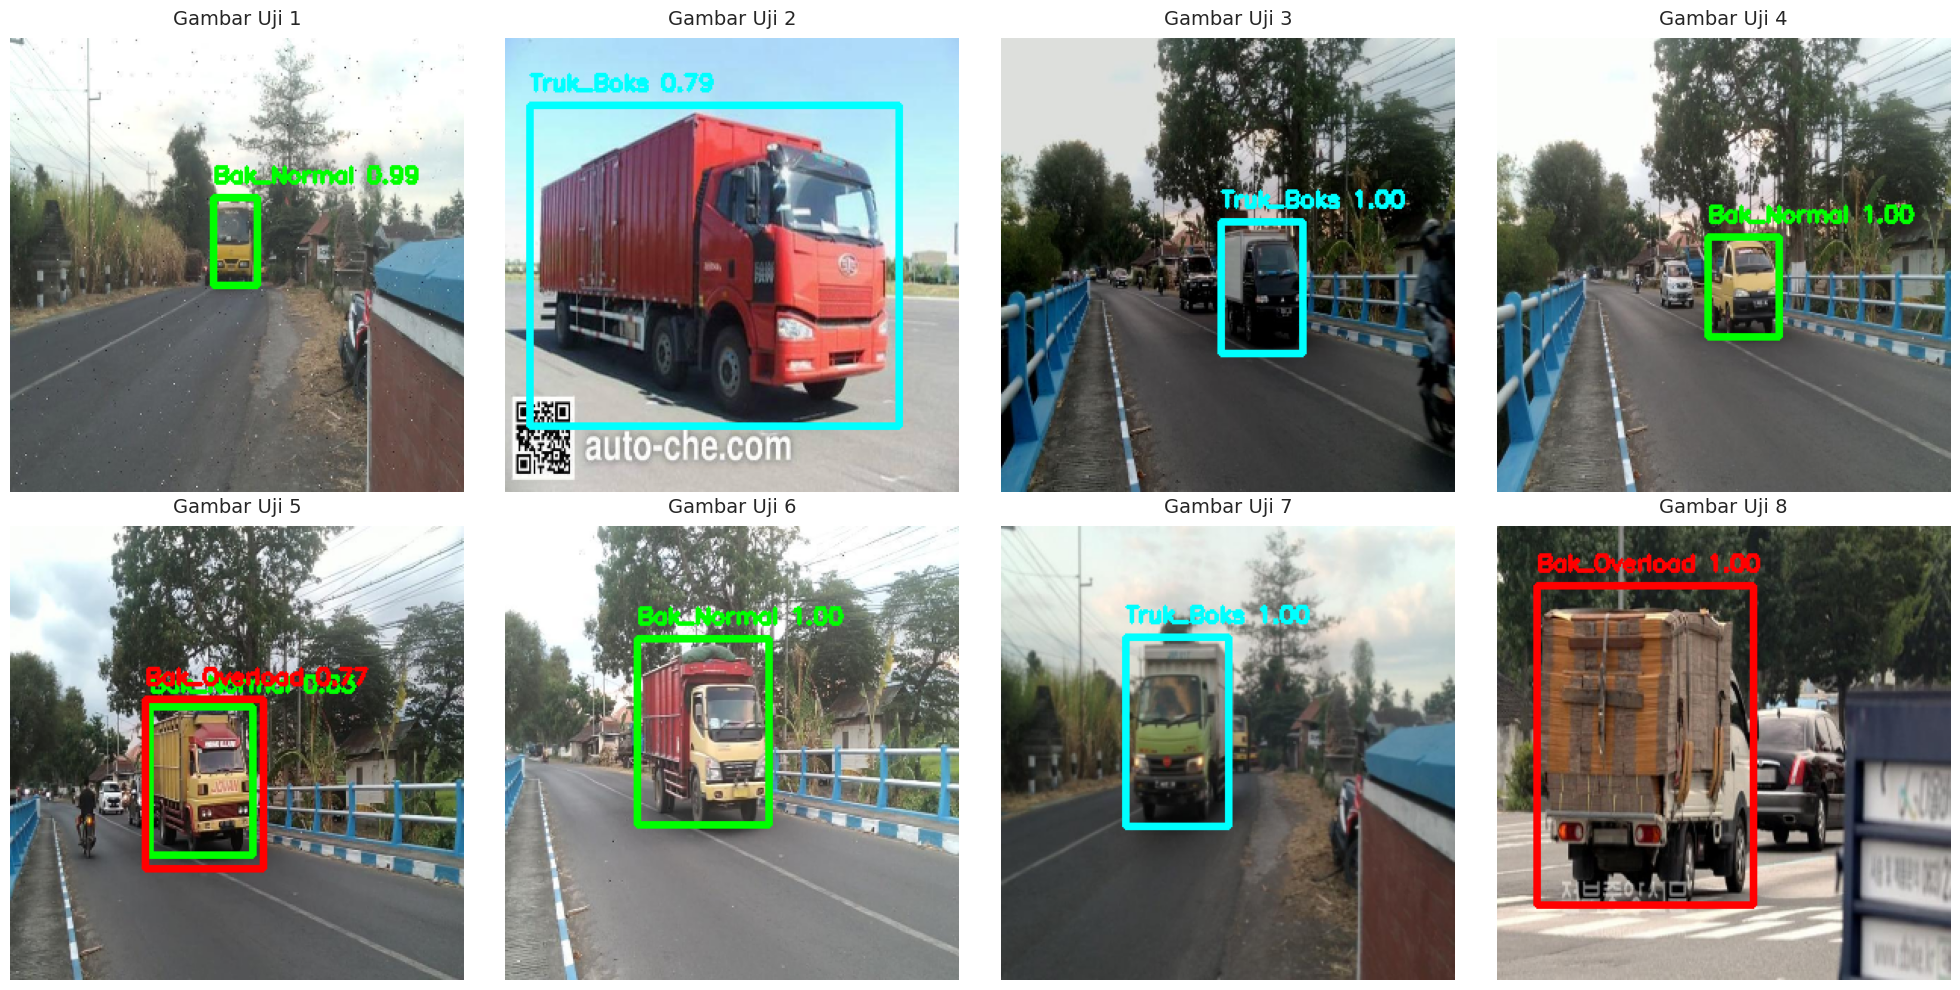

In [ ]:
import random
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch

print("1. Mempersiapkan model SSD terbaik...")
model.eval()

print("2. Mengambil 8 gambar acak dari data Test...\n")
if len(test_dataset) >= 8:
    indeks_acak = random.sample(range(len(test_dataset)), 8)
else:
    indeks_acak = list(range(len(test_dataset)))

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

CONF_THRESH = 0.5
warna_kelas = {
    1: (0, 255, 0),   # Hijau (Bak_Normal)
    2: (255, 0, 0),   # Merah (Bak_Overload)
    3: (0, 255, 255)  # Cyan (Truk_Boks)
}

with torch.no_grad():
    for i, idx in enumerate(indeks_acak):
        # Ambil gambar dari DataLoader
        img_tensor, _ = test_dataset[idx]
        pred = model([img_tensor.to(device)])[0]

        # Konversi tensor gambar kembali ke format Numpy/OpenCV
        img_numpy = img_tensor.permute(1, 2, 0).cpu().numpy()
        img_numpy = (img_numpy * 255).astype(np.uint8)
        img_numpy = np.ascontiguousarray(img_numpy)

        boxes = pred["boxes"].cpu().numpy()
        scores = pred["scores"].cpu().numpy()
        labels = pred["labels"].cpu().numpy()

        # Gambarkan kotak jika yakin di atas 50%
        for box, score, label in zip(boxes, scores, labels):
            if score >= CONF_THRESH:
                xmin, ymin, xmax, ymax = map(int, box)
                color = warna_kelas.get(label, (255, 255, 0)) # Default kuning jika ada error kelas

                cv2.rectangle(img_numpy, (xmin, ymin), (xmax, ymax), color, 3)
                nama_label = class_names[label - 1]
                label_text = f"{nama_label} {score:.2f}"
                cv2.putText(img_numpy, label_text, (xmin, ymin - 10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

        ax = axes[i]
        ax.imshow(img_numpy)
        ax.axis('off')
        ax.set_title(f"Gambar Uji {i+1}", fontsize=14, pad=10)

# Sembunyikan sisa kanvas jika gambar kurang dari 8
for j in range(i + 1, 8):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

CELL 8: Deteksi

In [ ]:
import os
import cv2
import torch
import subprocess
import numpy as np
from google.colab import files
from IPython.display import Video, Image as IPyImage, display

print("1. Memuat 'otak' model terbaik SSD...")
model.eval()

folder_simpan_bebas = '/content/drive/MyDrive/Evaluasi_ODOL/SSD_Hasil_Bebas'
os.makedirs(folder_simpan_bebas, exist_ok=True)

print("\n2. Silakan upload file tes kamu (.jpg, .jpeg, .png, .webp, atau .mp4):")
uploaded = files.upload()

if uploaded:
    file_name = list(uploaded.keys())[0]
    input_path = f'/content/{file_name}'
    ext = file_name.rsplit('.', 1)[-1].lower()

    print(f"\n[1/2] Memproses file: {file_name}...")

    CONF_THRESH = 0.4
    warna_kelas = {1: (0, 255, 0), 2: (255, 0, 0), 3: (0, 255, 255)}

    if ext in ['jpg', 'jpeg', 'png', 'webp']:
        # ==============================
        # PROSES JIKA FILE ADALAH FOTO
        # ==============================
        img = cv2.imread(input_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_tensor = torch.tensor(img_rgb.astype(np.float32) / 255.0).permute(2, 0, 1).to(device)

        with torch.no_grad():
            pred = model([img_tensor])[0]

        boxes = pred["boxes"].cpu().numpy()
        scores = pred["scores"].cpu().numpy()
        labels = pred["labels"].cpu().numpy()

        for box, score, label in zip(boxes, scores, labels):
            if score >= CONF_THRESH:
                xmin, ymin, xmax, ymax = map(int, box)
                color = warna_kelas.get(label, (255, 255, 0))
                cv2.rectangle(img, (xmin, ymin), (xmax, ymax), color, 3)
                nama_label = class_names[label - 1]
                label_text = f"{nama_label} {score:.2f}"
                cv2.putText(img, label_text, (xmin, ymin - 15), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2, cv2.LINE_AA)

        output_image_path = os.path.join(folder_simpan_bebas, file_name.replace(f'.{ext}', '_SSD.jpg'))
        cv2.imwrite(output_image_path, img)

        print("\n" + "="*50)
        print("🎯 PROSES DETEKSI FOTO SELESAI!")
        print("="*50)

        display(IPyImage(filename=output_image_path, width=800))
        print(f"\n✅ File aman tersimpan di: {output_image_path}")

    elif ext in ['mp4', 'avi', 'mov']:
        # ==============================
        # PROSES JIKA FILE ADALAH VIDEO
        # ==============================
        cap = cv2.VideoCapture(input_path)
        fps = cap.get(cv2.CAP_PROP_FPS)
        w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

        nama_tanpa_ext = file_name.rsplit('.', 1)[0]
        avi_path = os.path.join(folder_simpan_bebas, f"{nama_tanpa_ext}_temp.avi")
        fourcc = cv2.VideoWriter_fourcc(*'XVID')
        out = cv2.VideoWriter(avi_path, fourcc, fps, (w, h))

        with torch.no_grad():
            while cap.isOpened():
                ret, frame = cap.read()
                if not ret: break

                frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                img_tensor = torch.tensor(frame_rgb.astype(np.float32) / 255.0).permute(2, 0, 1).to(device)
                pred = model([img_tensor])[0]

                boxes = pred["boxes"].cpu().numpy()
                scores = pred["scores"].cpu().numpy()
                labels = pred["labels"].cpu().numpy()

                for box, score, label in zip(boxes, scores, labels):
                    if score >= CONF_THRESH:
                        xmin, ymin, xmax, ymax = map(int, box)
                        color = warna_kelas.get(label, (255, 255, 0))
                        cv2.rectangle(frame, (xmin, ymin), (xmax, ymax), color, 3)
                        nama_label = class_names[label - 1]
                        label_text = f"{nama_label} {score:.2f}"
                        cv2.putText(frame, label_text, (xmin, ymin - 15), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2, cv2.LINE_AA)
                out.write(frame)

        cap.release()
        out.release()

        print("[2/2] Mengonversi video agar bisa diputar di Colab...")
        mp4_final_path = os.path.join(folder_simpan_bebas, f"{nama_tanpa_ext}_FINAL_SSD.mp4")
        if os.path.exists(mp4_final_path): os.remove(mp4_final_path)

        subprocess.run([
            'ffmpeg', '-y', '-i', avi_path, '-vcodec', 'libx264', '-crf', '25', mp4_final_path, '-loglevel', 'quiet'
        ])

        if os.path.exists(avi_path): os.remove(avi_path)

        print("\n" + "="*50)
        print("🎯 PROSES DETEKSI VIDEO SELESAI!")
        print("="*50)

        display(Video(mp4_final_path, embed=True, width=600))
        print(f"\n✅ Video aman tersimpan permanen di: {mp4_final_path}")
    else:
        print("❌ Format file tidak dikenali. Harap upload gambar atau video yang sesuai.")
else:
    print("Upload dibatalkan.")

1. Memuat 'otak' model terbaik SSD...

2. Silakan upload file tes kamu (.jpg, .jpeg, .png, .webp, atau .mp4):


Saving contoh tes.mp4 to contoh tes (1).mp4

[1/2] Memproses file: contoh tes (1).mp4...
[2/2] Mengonversi video agar bisa diputar di Colab...

🎯 PROSES DETEKSI VIDEO SELESAI!



✅ Video aman tersimpan permanen di: /content/drive/MyDrive/Evaluasi_ODOL/SSD_Hasil_Bebas/contoh tes (1)_FINAL_SSD.mp4


1. Memuat 'otak' model terbaik SSD...

2. Silakan upload file tes kamu (.jpg, .jpeg, .png, .webp, atau .mp4):


Saving image_870x580_6489c0c75e009.jpg to image_870x580_6489c0c75e009 (1).jpg

[1/2] Memproses file: image_870x580_6489c0c75e009 (1).jpg...

🎯 PROSES DETEKSI FOTO SELESAI!


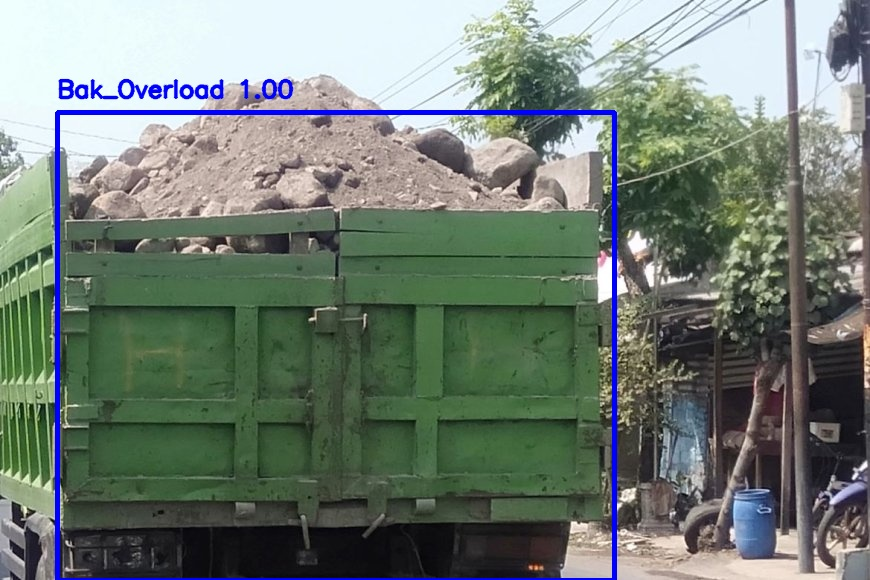


✅ File aman tersimpan di: /content/drive/MyDrive/Evaluasi_ODOL/SSD_Hasil_Bebas/image_870x580_6489c0c75e009 (1)_SSD.jpg


In [ ]:
import os
import cv2
import torch
import subprocess
import numpy as np
from google.colab import files
from IPython.display import Video, Image as IPyImage, display

print("1. Memuat 'otak' model terbaik SSD...")
model.eval()

folder_simpan_bebas = '/content/drive/MyDrive/Evaluasi_ODOL/SSD_Hasil_Bebas'
os.makedirs(folder_simpan_bebas, exist_ok=True)

print("\n2. Silakan upload file tes kamu (.jpg, .jpeg, .png, .webp, atau .mp4):")
uploaded = files.upload()

if uploaded:
    file_name = list(uploaded.keys())[0]
    input_path = f'/content/{file_name}'
    ext = file_name.rsplit('.', 1)[-1].lower()

    print(f"\n[1/2] Memproses file: {file_name}...")

    CONF_THRESH = 0.4
    warna_kelas = {1: (0, 255, 0), 2: (255, 0, 0), 3: (0, 255, 255)}

    if ext in ['jpg', 'jpeg', 'png', 'webp']:
        # ==============================
        # PROSES JIKA FILE ADALAH FOTO
        # ==============================
        img = cv2.imread(input_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_tensor = torch.tensor(img_rgb.astype(np.float32) / 255.0).permute(2, 0, 1).to(device)

        with torch.no_grad():
            pred = model([img_tensor])[0]

        boxes = pred["boxes"].cpu().numpy()
        scores = pred["scores"].cpu().numpy()
        labels = pred["labels"].cpu().numpy()

        for box, score, label in zip(boxes, scores, labels):
            if score >= CONF_THRESH:
                xmin, ymin, xmax, ymax = map(int, box)
                color = warna_kelas.get(label, (255, 255, 0))
                cv2.rectangle(img, (xmin, ymin), (xmax, ymax), color, 3)
                nama_label = class_names[label - 1]
                label_text = f"{nama_label} {score:.2f}"
                cv2.putText(img, label_text, (xmin, ymin - 15), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2, cv2.LINE_AA)

        output_image_path = os.path.join(folder_simpan_bebas, file_name.replace(f'.{ext}', '_SSD.jpg'))
        cv2.imwrite(output_image_path, img)

        print("\n" + "="*50)
        print("🎯 PROSES DETEKSI FOTO SELESAI!")
        print("="*50)

        display(IPyImage(filename=output_image_path, width=800))
        print(f"\n✅ File aman tersimpan di: {output_image_path}")

    elif ext in ['mp4', 'avi', 'mov']:
        # ==============================
        # PROSES JIKA FILE ADALAH VIDEO
        # ==============================
        cap = cv2.VideoCapture(input_path)
        fps = cap.get(cv2.CAP_PROP_FPS)
        w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

        nama_tanpa_ext = file_name.rsplit('.', 1)[0]
        avi_path = os.path.join(folder_simpan_bebas, f"{nama_tanpa_ext}_temp.avi")
        fourcc = cv2.VideoWriter_fourcc(*'XVID')
        out = cv2.VideoWriter(avi_path, fourcc, fps, (w, h))

        with torch.no_grad():
            while cap.isOpened():
                ret, frame = cap.read()
                if not ret: break

                frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                img_tensor = torch.tensor(frame_rgb.astype(np.float32) / 255.0).permute(2, 0, 1).to(device)
                pred = model([img_tensor])[0]

                boxes = pred["boxes"].cpu().numpy()
                scores = pred["scores"].cpu().numpy()
                labels = pred["labels"].cpu().numpy()

                for box, score, label in zip(boxes, scores, labels):
                    if score >= CONF_THRESH:
                        xmin, ymin, xmax, ymax = map(int, box)
                        color = warna_kelas.get(label, (255, 255, 0))
                        cv2.rectangle(frame, (xmin, ymin), (xmax, ymax), color, 3)
                        nama_label = class_names[label - 1]
                        label_text = f"{nama_label} {score:.2f}"
                        cv2.putText(frame, label_text, (xmin, ymin - 15), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2, cv2.LINE_AA)
                out.write(frame)

        cap.release()
        out.release()

        print("[2/2] Mengonversi video agar bisa diputar di Colab...")
        mp4_final_path = os.path.join(folder_simpan_bebas, f"{nama_tanpa_ext}_FINAL_SSD.mp4")
        if os.path.exists(mp4_final_path): os.remove(mp4_final_path)

        subprocess.run([
            'ffmpeg', '-y', '-i', avi_path, '-vcodec', 'libx264', '-crf', '25', mp4_final_path, '-loglevel', 'quiet'
        ])

        if os.path.exists(avi_path): os.remove(avi_path)

        print("\n" + "="*50)
        print("🎯 PROSES DETEKSI VIDEO SELESAI!")
        print("="*50)

        display(Video(mp4_final_path, embed=True, width=600))
        print(f"\n✅ Video aman tersimpan permanen di: {mp4_final_path}")
    else:
        print("❌ Format file tidak dikenali. Harap upload gambar atau video yang sesuai.")
else:
    print("Upload dibatalkan.")

CELL 9: Persiapan Ekspor

In [ ]:
from google.colab import files
import os

print("Mencari file model terbaik SSD di Google Drive...")

# Lokasi penyimpanan model SSD terbaik yang sudah kita set di Cell 4
path_model_ssd = '/content/drive/MyDrive/Evaluasi_ODOL/SSD_Hasil/best_ssd.pth'

if os.path.exists(path_model_ssd):
    print("✅ File 'best_ssd.pth' ditemukan! Memulai proses unduh...")
    files.download(path_model_ssd)
    print("📥 Tunggu sebentar, file sedang diunduh. Silakan cek folder 'Downloads' di laptop Anda nanti.")
else:
    print("❌ Model tidak ditemukan. Pastikan proses training di Cell 4 sudah tuntas.")

Mencari file model terbaik SSD di Google Drive...
✅ File 'best_ssd.pth' ditemukan! Memulai proses unduh...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Tunggu sebentar, file sedang diunduh. Silakan cek folder 'Downloads' di laptop Anda nanti.
